# PoC 2 — SPLADE (C) + Query Expansion (B) + Client-side RRF (D) + Benchmark

**Goal:** Replace BM25 with open-source **SPLADE** (Sparse Lexical and
Expansion model) — the free, open alternative to Elasticsearch's proprietary
ELSER. Combine it with dense kNN and query expansion, fuse with client-side
RRF, then run a **complete head-to-head benchmark** against PoC-1.

| Component | Implementation | License |
|-----------|---------------|----------|
| **B – Query expansion** | Rule-based + Ollama | Free |
| **C – SPLADE sparse** | `naver/splade-cocondenser-selfdistil` | MIT |
| **D – RRF fusion** | Pure Python | Free |
| Dense kNN | `all-mpnet-base-v2` (same as PoC-1) | Apache-2.0 |

SPLADE produces a **weighted sparse vocabulary vector** (similar to ELSER but
fully open-source) that is stored in a `sparse_vector` field in ES — a free
field type available on all license tiers.

**Prerequisites:**
- Notebook 01 run → `neuroimaging` index exists
- Notebook 06 run → `neuroimaging-poc1` exists + `poc1_results.json` saved

In [ ]:
import os

# ── Configuration ────────────────────────────────────────────────────────────
ES_HOST = os.environ.get("ES_HOST", "http://localhost:9200")
BASE_INDEX = "neuroimaging"
POC1_INDEX = "neuroimaging-poc1"
POC2_INDEX = "neuroimaging-poc2"

DENSE_MODEL = "all-mpnet-base-v2"   # same as PoC-1 for fair comparison
DENSE_DIMS = 768

# SPLADE model — doc + query encoder
# Alternative: "naver/splade-v3" (better quality, ~2× larger)
SPLADE_MODEL = "naver/splade-cocondenser-selfdistil"
SPLADE_WEIGHT_THRESHOLD = 0.01  # ignore tokens below this weight

RRF_K = 60
TOP_K = 5

POC1_RESULTS_PATH = "poc1_results.json"  # written by Notebook 06

In [ ]:
import json
import time
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from elasticsearch import Elasticsearch, helpers
import warnings
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


client = Elasticsearch(ES_HOST, request_timeout=120)
assert client.ping(), f"Cannot reach Elasticsearch at {ES_HOST}"
print(f"Connected to ES {client.info()['version']['number']}")

print(f"Loading dense encoder: {DENSE_MODEL} ...")
dense_model = SentenceTransformer(DENSE_MODEL, device='cpu')
print(
    f"Dense encoder ready. dims={dense_model.get_sentence_embedding_dimension()}")

# SPLADE (loaded in next section)
splade_encoder = None

Connected to ES 9.3.0
Loading dense encoder: all-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dense encoder ready. dims=768


## Option B — Query Expansion (identical to PoC-1)

Same module as Notebook 06 so both PoCs receive identical query preprocessing.

In [ ]:
import os
import urllib.request as _ureq
import json as _json
import re

_OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
OLLAMA_URL = _OLLAMA_HOST + "/api/generate"

OLLAMA_PROMPT = (
    "You are a neuroimaging search assistant. Expand a short user query into richer "
    "BIDS-aware search terms that find the most relevant files in an Elasticsearch "
    "index of neuroimaging metadata.\\n\\n"
    "BIDS suffixes: bold=BOLD fMRI, T1w=structural anatomical, T2w=T2-weighted, "
    "dwi=Diffusion Weighted Imaging, phasediff/magnitude1/magnitude2/epi=fieldmap, "
    "UNIT1=MP2RAGE uniform T1, T1map=quantitative T1 relaxometry, "
    "asl=Arterial Spin Labeling perfusion, m0scan=ASL M0 reference, pet=PET.\\n\\n"
    "Key fields: suffix, task/TaskName, MagneticFieldStrength (1.5/3/7 T), "
    "Manufacturer (Siemens/Philips/GE), RepetitionTime (s), InversionTime (ms).\\n\\n"
    "Corpus: ds001-ds116 (fMRI/structural), 7t_trt (7T), "
    "qmri_mp2rage/qmri_irt1/qmri_mese/qmri_vfa (qMRI), "
    "asl001-asl005 (perfusion), ds000117 (fMRI+MEG).\\n\\n"
    "Rules: expand abbreviations; add field=value tokens; include synonyms. "
    "Output ONLY space-separated search terms — no explanation, no JSON, no markdown.\\n"
    "Query: {query}\\nExpanded:"
)

SYNONYM_MAP = {
    "resting state":   "resting state rest TaskName=rest task=rest rsfMRI default-mode-network spontaneous",
    "resting-state":   "resting state rest TaskName=rest task=rest rsfMRI",
    "resting":         "resting rest TaskName=rest rsfMRI",
    "fmri":            "fMRI BOLD bold functional Blood-Oxygen-Level-Dependent suffix=bold",
    "functional":      "functional fMRI BOLD bold suffix=bold activation",
    "diffusion":       "diffusion DWI dwi DTI dti white-matter tractography b-value bvec bval",
    "dti":             "DTI DWI diffusion tensor imaging white matter b0",
    "dwi":             "DWI DTI diffusion weighted imaging b-value bvec bval",
    "anatomical":      "anatomical structural T1w T2w MPRAGE MP2RAGE brain morphology",
    "structural":      "structural anatomical T1w MPRAGE MP2RAGE suffix=T1w",
    "t1":              "T1w T1 structural anatomical MPRAGE UNIT1",
    "t2":              "T2w T2 structural spin-echo suffix=T2w",
    "flair":           "FLAIR T2 fluid attenuated inversion recovery",
    "mapping":         "quantitative qMRI relaxometry T1map T2map suffix=T1map InversionTime",
    "quantitative":    "quantitative qMRI relaxometry suffix=T1map InversionTime FlipAngle",
    "mp2rage":         "MP2RAGE UNIT1 suffix=UNIT1 inversion-recovery two-inversion ultra-high-field",
    "asl":             "ASL arterial-spin-labeling suffix=asl m0scan perfusion cerebral-blood-flow CBF",
    "perfusion":       "perfusion ASL arterial-spin-labeling suffix=asl m0scan CBF",
    "fieldmap":        "fieldmap phasediff magnitude1 magnitude2 epi distortion-correction B0 suffix=phasediff",
    "3t":              "3T 3Tesla MagneticFieldStrength=3 three-Tesla",
    "1.5t":            "1.5T MagneticFieldStrength=1.5",
    "7t":              "7T 7Tesla MagneticFieldStrength=7 ultra-high-field",
    "siemens":         "Siemens TrioTim Prisma Skyra Verio Manufacturer=Siemens",
    "philips":         "Philips Achieva Ingenia Manufacturer=Philips",
    "ge":              "GE Discovery Signa Manufacturer=GE General-Electric",
    "bold":            "BOLD fMRI bold suffix=bold functional Blood-Oxygen-Level-Dependent",
    "brain":           "brain neuroimaging MRI neural cortex cerebral",
    "high resolution": "high-resolution MPRAGE MP2RAGE 1mm isotropic sub-millimetre",
}


def _llm_expand(query, ollama_model="llama3"):
    try:
        payload = {"model": ollama_model,
                   "prompt": OLLAMA_PROMPT.format(query=query),
                   "stream": False}
        req = _ureq.Request(OLLAMA_URL, data=_json.dumps(payload).encode(),
                            headers={"Content-Type": "application/json"}, method="POST")
        with _ureq.urlopen(req, timeout=20) as resp:
            return _json.loads(resp.read()).get("response", "").strip()
    except Exception:
        return None


def _rule_expand(query):
    lower = query.lower()
    extra = [exp for kw, exp in SYNONYM_MAP.items()
             if re.search(r'\b' + re.escape(kw) + r'\b', lower)]
    return (query + " " + " ".join(extra)).strip() if extra else query


def expand_query(query):
    llm = _llm_expand(query)
    if llm:
        return llm, "ollama"
    return _rule_expand(query), "rule-based"


print("Query expansion ready.")

Query expansion ready.


In [ ]:
# Client-side RRF (identical to PoC-1 — no ES license required)
def rrf_fuse(hit_lists, k=RRF_K):
    scores, sources = {}, {}
    for hits in hit_lists:
        for rank, hit in enumerate(hits, start=1):
            doc_id = hit["_id"]
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
            sources[doc_id] = hit.get("_source", {})
    return [
        {"_id": doc_id, "_score": score, "_source": sources[doc_id]}
        for doc_id, score in sorted(scores.items(), key=lambda x: -x[1])
    ]


print("Client-side RRF ready.")

Client-side RRF ready.


## Option C — SPLADE Sparse Encoder

SPLADE (Sparse Lexical and Expansion) is the open-source equivalent of
Elasticsearch's proprietary ELSER. It uses a masked-language-model (BERT)
to predict which vocabulary tokens best represent a text, producing a
**weighted sparse vector** that can be stored in ES's `sparse_vector` field.

Key differences vs. BM25:

| | BM25 | SPLADE |
|--|------|--------|
| Synonym expansion | ❌ no | ✅ learned |
| Context-aware weights | ❌ TF-IDF only | ✅ contextual |
| Training | none | MS-MARCO + self-distill |
| Requires GPU | — | optional (CPU works) |

The model downloads ~440 MB on first use.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM


class SPLADEEncoder:
    """SPLADE-style sparse encoder using HuggingFace transformers."""

    def __init__(self, model_name: str = SPLADE_MODEL, max_length: int = 256):
        print(f"Loading SPLADE: {model_name} ...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForMaskedLM.from_pretrained(model_name)
        self.model.eval()
        self.max_length = max_length
        self.device = "cpu"  # Force CPU-only (no GPU)
        self.model.to(self.device)
        print(f"SPLADE ready on {self.device}.")

    @torch.no_grad()
    def _forward(self, tokens) -> torch.Tensor:
        tokens = {k: v.to(self.device) for k, v in tokens.items()}
        logits = self.model(**tokens).logits        # [B, seq_len, vocab]
        # SPLADE aggregation: max-pool then log1p(relu(.))
        sparse = torch.max(
            torch.log1p(torch.relu(logits))
            * tokens["attention_mask"].unsqueeze(-1),
            dim=1
        )[0]  # [B, vocab]
        return sparse

    def encode(self, text: str) -> dict[str, float]:
        """Encode a single text → {token: weight} sparse dict."""
        tokens = self.tokenizer(
            text, return_tensors="pt",
            max_length=self.max_length, truncation=True
        )
        sparse = self._forward(tokens).squeeze(0)   # [vocab]
        indices = (sparse > SPLADE_WEIGHT_THRESHOLD).nonzero(as_tuple=True)[0]
        return {
            self.tokenizer.convert_ids_to_tokens(int(idx)).replace("##", ""):
            float(sparse[idx])
            for idx in indices
        }

    def encode_batch(self, texts: list[str]) -> list[dict[str, float]]:
        """Batch-encode for faster ingest."""
        tokens = self.tokenizer(
            texts, return_tensors="pt",
            max_length=self.max_length, truncation=True, padding=True
        )
        sparse = self._forward(tokens)   # [B, vocab]
        results = []
        attn = tokens["attention_mask"]  # [B, seq_len]
        for i in range(sparse.shape[0]):
            row = sparse[i]
            indices = (row > SPLADE_WEIGHT_THRESHOLD).nonzero(as_tuple=True)[0]
            results.append({
                self.tokenizer.convert_ids_to_tokens(int(idx)).replace("##", ""):
                float(row[idx]) for idx in indices
            })
        return results


splade_encoder = SPLADEEncoder()

# Smoke test
test_vec = splade_encoder.encode("resting state fMRI")
top5 = sorted(test_vec.items(), key=lambda x: -x[1])[:5]
print(f"SPLADE top-5 tokens for 'resting state fMRI': {top5}")
print(f"Vocabulary coverage: {len(test_vec)} non-zero tokens")

Loading SPLADE: naver/splade-cocondenser-selfdistil ...


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: naver/splade-cocondenser-selfdistil
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SPLADE ready on cpu.
SPLADE top-5 tokens for 'resting state fMRI': [('resting', 2.53371000289917), ('state', 2.3986148834228516), ('fm', 2.372370958328247), ('ri', 2.2826969623565674), ('rest', 2.274512529373169)]
Vocabulary coverage: 58 non-zero tokens


## Index Setup — `neuroimaging-poc2`

The PoC-2 index has **two vector fields** per document:
- `sparse_embedding` — SPLADE sparse vector (replaces BM25 as sparse retriever)
- `metadata_embedding` — all-mpnet-base-v2 dense vector (same as PoC-1)

The `sparse_vector` field type is free on all ES license tiers.

In [ ]:
POC2_MAPPINGS = {
    "properties": {
        "dataset":   {"type": "keyword"},
        "subject":   {"type": "keyword"},
        "session":   {"type": "keyword"},
        "task":      {"type": "keyword"},
        "run":       {"type": "keyword"},
        "suffix":    {"type": "keyword"},
        "datatype":  {"type": "keyword"},
        "age":       {"type": "float"},
        "sex":       {"type": "keyword"},
        "RepetitionTime":        {"type": "float"},
        "EchoTime":              {"type": "float"},
        "FlipAngle":             {"type": "float"},
        "MagneticFieldStrength": {"type": "float"},
        "SliceThickness":        {"type": "float"},
        "InversionTime":         {"type": "float"},
        "Manufacturer":           {"type": "keyword"},
        "ManufacturersModelName": {"type": "keyword"},
        "InstitutionName":        {"type": "keyword"},
        "PhaseEncodingDirection": {"type": "keyword"},
        "TaskName":          {"type": "text"},
        "SeriesDescription": {"type": "text"},
        "description_text":  {"type": "text"},
        # SPLADE sparse vector — free field type on Basic license
        "sparse_embedding": {"type": "sparse_vector"},
        # Dense vector — same model as PoC-1 for fair comparison
        "metadata_embedding": {
            "type": "dense_vector",
            "dims": DENSE_DIMS,
            "similarity": "cosine",
            "index_options": {"type": "int8_hnsw"},
        },
        "bids_path": {"type": "keyword"},
    }
}

if client.indices.exists(index=POC2_INDEX):
    doc_count = client.count(index=POC2_INDEX)["count"]
    print(
        f"Index {POC2_INDEX!r} already exists with {doc_count} docs — skipping creation.")
else:
    if not client.indices.exists(index=BASE_INDEX):
        raise RuntimeError(
            f"Base index {BASE_INDEX!r} not found. Run Notebook 01 first.")
    client.indices.create(
        index=POC2_INDEX,
        settings={"number_of_replicas": 0},
        mappings=POC2_MAPPINGS
    )
    print(
        f"Created index {POC2_INDEX!r} with sparse_vector + dense_vector fields.")

Index 'neuroimaging-poc2' already exists with 4423 docs — skipping creation.


In [ ]:
# ── Ingest: fetch → SPLADE + dense embed → bulk-index ───────────────────────

def fetch_all_docs(index, batch_size=500):
    docs, from_ = [], 0
    while True:
        resp = client.search(
            index=index, query={"match_all": {}},
            size=batch_size, from_=from_,
            source_excludes=["metadata_embedding", "sparse_embedding"]
        )
        hits = resp["hits"]["hits"]
        if not hits:
            break
        docs.extend(hits)
        from_ += len(hits)
        if from_ >= resp["hits"]["total"]["value"]:
            break
    return docs


def batches(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]


if client.count(index=POC2_INDEX)["count"] == 0:
    print(f"Fetching documents from {BASE_INDEX!r} ...")
    base_docs = fetch_all_docs(BASE_INDEX)
    total = len(base_docs)
    print(
        f"Fetched {total} documents. Computing SPLADE + dense embeddings ...")
    print("(This is slower than PoC-1: SPLADE runs on CPU, ~2-3× longer)")

    actions = []
    BATCH_SIZE = 16   # smaller batches for SPLADE memory
    for batch in tqdm(list(batches(base_docs, BATCH_SIZE)), desc="SPLADE + dense"):
        texts = [d["_source"].get("description_text", "") for d in batch]

        # Dense embeddings (fast)
        dense_vecs = dense_model.encode(
            texts, show_progress_bar=False).tolist()

        # SPLADE sparse embeddings
        sparse_vecs = splade_encoder.encode_batch(texts)

        for doc, dense_vec, sparse_vec in zip(batch, dense_vecs, sparse_vecs):
            src = doc["_source"].copy()
            src["metadata_embedding"] = dense_vec
            src["sparse_embedding"] = sparse_vec
            actions.append(
                {"_index": POC2_INDEX, "_id": doc["_id"], "_source": src})

    helpers.bulk(client, actions, chunk_size=100)
    client.indices.refresh(index=POC2_INDEX)
    print(f"Indexed {len(actions)} docs into {POC2_INDEX!r}")
else:
    print(f"Index {POC2_INDEX!r} already populated — skipping ingest.")

print(
    f"Total docs in {POC2_INDEX!r}: {client.count(index=POC2_INDEX)['count']}")

Index 'neuroimaging-poc2' already populated — skipping ingest.
Total docs in 'neuroimaging-poc2': 4423


## PoC-2 Search Functions

Three retrievers are run separately, then fused with RRF:

| Retriever | ES query type | What it does |
|-----------|--------------|--------------|  
| BM25 | `match` on `description_text` | Baseline term matching |
| SPLADE | `sparse_vector` on `sparse_embedding` | Contextual sparse retrieval |
| Dense kNN | `knn` on `metadata_embedding` | Semantic dense retrieval |

RRF can fuse any combination. Default: all three.

In [ ]:
def poc2_search(
    query: str,
    retrievers: tuple = ("bm25", "splade", "knn"),  # choose which to fuse
    expand: bool = True,
    k: int = TOP_K,
    num_candidates: int = 100,
) -> tuple[list[dict], dict]:
    """
    Run PoC-2 search: SPLADE sparse + dense kNN + BM25, fused with client-side RRF.

    Parameters
    ----------
    query      : raw user query
    retrievers : subset of ("bm25", "splade", "knn") to include in fusion
    expand     : apply query expansion before all retrievers
    """
    t0 = time.perf_counter()
    expanded, backend = expand_query(query) if expand else (query, "none")

    hit_lists = []

    if "bm25" in retrievers:
        resp = client.search(
            index=POC2_INDEX,
            query={"match": {"description_text": expanded}},
            size=k * 3
        )
        hit_lists.append(resp["hits"]["hits"])

    if "splade" in retrievers:
        sparse_vec = splade_encoder.encode(expanded)
        resp = client.search(
            index=POC2_INDEX,
            query={"sparse_vector": {"field": "sparse_embedding",
                                     "query_vector": sparse_vec}},
            size=k * 3
        )
        hit_lists.append(resp["hits"]["hits"])

    if "knn" in retrievers:
        resp = client.search(
            index=POC2_INDEX,
            knn={"field": "metadata_embedding",
                 "query_vector": dense_model.encode(expanded,
                                                    show_progress_bar=False).tolist(),
                 "k": k * 3, "num_candidates": num_candidates * 2},
        )
        hit_lists.append(resp["hits"]["hits"])

    hits = rrf_fuse(hit_lists)[:k]
    latency_ms = (time.perf_counter() - t0) * 1000
    meta = {"query": query, "expanded": expanded, "backend": backend,
            "retrievers": list(retrievers), "latency_ms": round(latency_ms, 1)}
    return hits, meta


def show_hits(hits, fields=None):
    rows = []
    for hit in hits:
        row = {"_score": round(float(hit.get("_score") or 0), 5)}
        src = hit.get("_source", {})
        for f in (fields or ["dataset", "suffix", "Manufacturer",
                             "MagneticFieldStrength", "TaskName", "description_text"]):
            row[f] = src.get(f)
        rows.append(row)
    return pd.DataFrame(rows)

## Demo — SPLADE vs BM25 vs Dense kNN vs Full RRF Fusion

In [ ]:
DEMO_QUERIES = [
    "resting state fMRI on a Siemens 3T scanner",
    "diffusion weighted imaging white matter tractography",
    "high resolution T1 anatomical structural brain",
]

for q in DEMO_QUERIES:
    print(f"\n{'='*70}")
    print(f"QUERY: {q!r}")

    configs = [
        ("BM25 only",                ("bm25",)),
        ("SPLADE only (C)",           ("splade",)),
        ("Dense kNN only",            ("knn",)),
        ("SPLADE + kNN RRF",          ("splade", "knn")),
        ("Full: BM25+SPLADE+kNN RRF", ("bm25", "splade", "knn")),
    ]

    for label, retrievers in configs:
        hits, meta = poc2_search(q, retrievers=retrievers, expand=True)
        scores = [round(float(h["_score"] or 0), 4) for h in hits]
        suffixes = [h["_source"].get("suffix", "?") for h in hits]
        print(f"\n  [{label:42s}]  {meta['latency_ms']:6.1f} ms")
        print(f"    scores : {scores}")
        print(f"    suffix : {suffixes}")


QUERY: 'resting state fMRI on a Siemens 3T scanner'

  [BM25 only                                 ]  20055.8 ms
    scores : [0.0164, 0.0161, 0.0159, 0.0156, 0.0154]
    suffix : ['bold', 'bold', 'bold', 'bold', 'bold']

  [SPLADE only (C)                           ]  20360.7 ms
    scores : [0.0164, 0.0161, 0.0159, 0.0156, 0.0154]
    suffix : ['bold', 'bold', 'bold', 'bold', 'bold']

  [Dense kNN only                            ]  21681.0 ms
    scores : [0.0164, 0.0161, 0.0159, 0.0156, 0.0154]
    suffix : ['bold', 'bold', 'bold', 'bold', 'bold']

  [SPLADE + kNN RRF                          ]  20374.6 ms
    scores : [0.0308, 0.0303, 0.0299, 0.0299, 0.0298]
    suffix : ['bold', 'bold', 'bold', 'bold', 'bold']

  [Full: BM25+SPLADE+kNN RRF                 ]  20315.9 ms
    scores : [0.0472, 0.046, 0.0457, 0.0444, 0.0442]
    suffix : ['bold', 'bold', 'bold', 'bold', 'bold']

QUERY: 'diffusion weighted imaging white matter tractography'

  [BM25 only                                

---
## Benchmark — PoC-1 vs PoC-2

### Methodology

Since we have no human-annotated relevance labels, we use **ground-truth
metadata** as a proxy: for each query we know which document field values
constitute a correct answer (e.g., `suffix == 'bold'` for a BOLD query).

**Metrics computed per query:**

| Metric | Meaning |
|--------|---------|
| **P@3 / P@5 / P@10** | Precision at k — fraction of top-k results that are correct |
| **MRR** | Mean Reciprocal Rank — 1/rank of first correct result |
| **Score spread (σ)** | Std-dev of scores — higher means more discriminative |
| **Latency (ms)** | Wall-clock time for the full search call |
| **Novel docs** | Results found by one system but not the other |

**Gold queries** cover 10 neuroimaging use-cases with unambiguous expected
metadata values.

In [ ]:
# ── GOLD_QUERIES — shared evaluation set (kept in sync with Notebook 06) ───
# Harder than the original set: multi-attribute checks, rare modalities, TR-range
# These cover the realistic search scenarios a neuroimager would care about.

GOLD_QUERIES = [
    # Modality retrieval
    {"query":  "Blood Oxygen Level Dependent fMRI task activation brain",
     "label":  "BOLD / fMRI",
     "check": lambda s: s.get("suffix") == "bold",
     "note":   "Any BOLD scan"},
    {"query":  "T1-weighted MPRAGE structural anatomical brain scan",
     "label":  "T1w structural",
     "check": lambda s: s.get("suffix") in ("T1w", "UNIT1", "FLASH"),
     "note":   "Structural MRI"},
    {"query":  "diffusion tensor DWI white-matter tractography b-value bvec",
     "label":  "DWI / diffusion",
     "check": lambda s: s.get("suffix") == "dwi",
     "note":   "DWI suffix"},
    {"query":  "phase-difference fieldmap B0 distortion correction EPI",
     "label":  "Fieldmap",
     "check": lambda s: s.get("suffix") in ("phasediff", "epi",
                                            "magnitude1", "magnitude2",
                                            "fieldmap"),
     "note":   "Fieldmap family"},
    # Scanner metadata
    {"query":  "Siemens MRI scanner TrioTim Prisma Skyra neuroimaging",
     "label":  "Siemens scanner",
     "check": lambda s: "siemens" in str(s.get("Manufacturer", "")).lower(),
     "note":   "Manufacturer + model names"},
    {"query":  "3 Tesla high-field MRI neuroimaging research scanner",
     "label":  "3T field strength",
     "check": lambda s: s.get("MagneticFieldStrength") == 3.0,
     "note":   "3T only"},
    {"query":  "ultra-high field 7 Tesla MRI B1 transmit homogeneity",
     "label":  "7T field strength",
     "check": lambda s: s.get("MagneticFieldStrength") == 7.0,
     "note":   "7T datasets"},
    # Task / paradigm
    {"query":  "resting state eyes-open spontaneous brain activity fMRI rest",
     "label":  "Resting-state fMRI",
     "check": lambda s: (
         s.get("suffix") == "bold"
         and ("rest" in str(s.get("task", "")).lower()
              or "rest" in str(s.get("TaskName", "")).lower())
     ),
     "note":   "BOLD + resting-state task"},
    {"query":  "cognitive task fMRI activation experimental paradigm",
     "label":  "Task-fMRI (non-rest)",
     "check": lambda s: (
         s.get("suffix") == "bold"
         and s.get("task") not in (None, "", "rest", "restingstate",
                                   "restingstate01", "rest1")
     ),
     "note":   "BOLD non-rest task"},
    # Quantitative / advanced
    {"query":  "quantitative MRI relaxometry T1 mapping inversion recovery MP2RAGE",
     "label":  "qMRI (T1map/UNIT1)",
     "check": lambda s: s.get("suffix") in ("T1map", "UNIT1", "IRT1", "VFA", "T1w")
     and s.get("InversionTime") is not None,
     "note":   "qMRI with InversionTime"},
    {"query":  "arterial spin labeling perfusion cerebral blood flow ASL",
     "label":  "ASL / perfusion",
     "check": lambda s: s.get("suffix") in ("asl", "m0scan"),
     "note":   "ASL rare modality"},
    {"query":  "short repetition time multiband EPI fast fMRI acquisition",
     "label":  "Short TR BOLD (TR<1.5s)",
     "check": lambda s: (
         s.get("suffix") == "bold"
         and s.get("RepetitionTime") is not None
         and float(s.get("RepetitionTime") or 99) < 1.5
     ),
     "note":   "TR range + modality combo"},
]


def precision_at_k(hits, check_fn, k):
    top = hits[:k]
    return sum(1 for h in top if check_fn(h["_source"])) / k if top else 0.0


def mean_reciprocal_rank(hits, check_fn, max_rank=10):
    for rank, hit in enumerate(hits[:max_rank], start=1):
        if check_fn(hit["_source"]):
            return 1.0 / rank
    return 0.0


def score_spread(hits):
    scores = [float(h.get("_score") or 0) for h in hits]
    return float(np.std(scores)) if len(scores) > 1 else 0.0


print(f"Benchmark ready: {len(GOLD_QUERIES)} gold queries")
for gq in GOLD_QUERIES:
    print(f"  [{gq['label']:30s}] {gq['note']}")

Benchmark ready: 12 gold queries
  [BOLD / fMRI                   ] Any BOLD scan
  [T1w structural                ] Structural MRI
  [DWI / diffusion               ] DWI suffix
  [Fieldmap                      ] Fieldmap family
  [Siemens scanner               ] Manufacturer + model names
  [3T field strength             ] 3T only
  [7T field strength             ] 7T datasets
  [Resting-state fMRI            ] BOLD + resting-state task
  [Task-fMRI (non-rest)          ] BOLD non-rest task
  [qMRI (T1map/UNIT1)            ] qMRI with InversionTime
  [ASL / perfusion               ] ASL rare modality
  [Short TR BOLD (TR<1.5s)       ] TR range + modality combo


In [ ]:
# ── Load PoC-1 results (from Notebook 06) ───────────────────────────────────
# If Notebook 06 was not run, we re-run PoC-1 queries here using the
# neuroimaging-poc1 index (must exist).

poc1_path = Path(POC1_RESULTS_PATH)

if poc1_path.exists():
    with open(poc1_path) as f:
        poc1_results = json.load(f)
    print(f"Loaded {len(poc1_results)} PoC-1 results from {poc1_path}")
else:
    print(f"{poc1_path} not found — re-running PoC-1 queries inline ...")
    # Import PoC-1 infrastructure inline
    from sentence_transformers import SentenceTransformer as _ST
    _poc1_model = _ST("all-mpnet-base-v2")

    def _poc1_embed(text):
        return _poc1_model.encode(text, show_progress_bar=False).tolist()

    def _poc1_rrf(bm25_hits, knn_hits):
        return rrf_fuse([bm25_hits, knn_hits])

    poc1_results = []
    for gq in tqdm(GOLD_QUERIES, desc="PoC-1 re-run"):
        expanded, backend = expand_query(gq["query"])
        t0 = time.perf_counter()
        b_resp = client.search(
            index=POC1_INDEX,
            query={"match": {"description_text": expanded}},
            size=30
        )
        k_resp = client.search(
            index=POC1_INDEX,
            knn={"field": "metadata_embedding", "query_vector": _poc1_embed(expanded),
                 "k": 30, "num_candidates": 200},
        )
        hits = _poc1_rrf(b_resp["hits"]["hits"], k_resp["hits"]["hits"])[:10]
        latency_ms = (time.perf_counter() - t0) * 1000
        poc1_results.append({
            "label":        gq["label"],
            "query":        gq["query"],
            "expanded":     expanded,
            "backend":      backend,
            "latency_ms":   round(latency_ms, 1),
            "p@3":  precision_at_k(hits, gq["check"], 3),
            "p@5":  precision_at_k(hits, gq["check"], 5),
            "p@10": precision_at_k(hits, gq["check"], 10),
            "mrr":  mean_reciprocal_rank(hits, gq["check"]),
            "score_spread": score_spread(hits),
            "hits": [{"_id": h["_id"], "_score": float(h.get("_score") or 0),
                      "_source": h["_source"]} for h in hits],
        })
    print(f"PoC-1 re-run complete: {len(poc1_results)} queries.")

Loaded 10 PoC-1 results from poc1_results.json


In [ ]:
# ── Run PoC-2 benchmark ──────────────────────────────────────────────────────
print("Running PoC-2 benchmark ...")

poc2_results = []
for gq in tqdm(GOLD_QUERIES, desc="PoC-2 queries"):
    hits, meta = poc2_search(gq["query"], retrievers=("bm25", "splade", "knn"),
                             expand=True, k=10)
    poc2_results.append({
        "label":        gq["label"],
        "query":        gq["query"],
        "expanded":     meta["expanded"],
        "backend":      meta["backend"],
        "latency_ms":   meta["latency_ms"],
        "p@3":  precision_at_k(hits, gq["check"], 3),
        "p@5":  precision_at_k(hits, gq["check"], 5),
        "p@10": precision_at_k(hits, gq["check"], 10),
        "mrr":  mean_reciprocal_rank(hits, gq["check"]),
        "score_spread": score_spread(hits),
        "hits": [{"_id": h["_id"], "_score": float(h.get("_score") or 0),
                  "_source": h["_source"]} for h in hits],
    })

print(f"PoC-2 complete: {len(poc2_results)} queries.")

Running PoC-2 benchmark ...


PoC-2 queries: 100%|██████████| 12/12 [02:14<00:00, 11.24s/it]

PoC-2 complete: 12 queries.


## Results — Side-by-Side Comparison

### Per-query metric table

In [ ]:
rows = []
for r1, r2, gq in zip(poc1_results, poc2_results, GOLD_QUERIES):
    rows.append({
        "Query":           r1["label"],
        "Note":            gq.get("note", ""),
        "PoC-1 P@5":       round(r1["p@5"], 2),
        "PoC-2 P@5":       round(r2["p@5"], 2),
        "Δ P@5":           round(r2["p@5"] - r1["p@5"], 2),
        "PoC-1 MRR":       round(r1["mrr"], 2),
        "PoC-2 MRR":       round(r2["mrr"], 2),
        "Δ MRR":           round(r2["mrr"] - r1["mrr"], 2),
        "PoC-1 ms":        round(r1["latency_ms"]),
        "PoC-2 ms":        round(r2["latency_ms"]),
    })

df_cmp = pd.DataFrame(rows)

# Highlight wins


def highlight_delta(val):
    if isinstance(val, float):
        if val > 0.05:
            return "background-color: #d4edda; color: #155724"  # green
        if val < -0.05:
            return "background-color: #f8d7da; color: #721c24"  # red
    return ""


display(df_cmp.style.map(highlight_delta, subset=["Δ P@5", "Δ MRR"]))

,Query,Note,PoC-1 P@5,PoC-2 P@5,Δ P@5,PoC-1 MRR,PoC-2 MRR,Δ MRR,PoC-1 ms,PoC-2 ms
0,BOLD suffix,Any BOLD scan,1.000000,0.600000,-0.400000,1.000000,1.000000,0.000000,12323,7525
1,T1w suffix,Structural MRI,0.400000,1.000000,0.600000,0.500000,1.000000,0.500000,8223,15138
2,DWI suffix,DWI suffix,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8386,12745
3,resting-state task,Fieldmap family,0.000000,0.400000,0.400000,0.000000,1.000000,1.000000,11201,11718
4,Siemens scanner,Manufacturer + model names,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,7084,14992
5,3T field strength,3T only,0.400000,0.600000,0.200000,0.500000,0.500000,0.000000,8516,9310
6,fieldmap suffix,7T datasets,0.400000,0.000000,-0.400000,0.500000,0.000000,-0.500000,10328,9326
7,high-res anatomical,BOLD + resting-state task,1.000000,0.600000,-0.400000,1.000000,1.000000,0.000000,15275,15394
8,task-fMRI,BOLD non-rest task,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,9407,6805
9,non-3T field,qMRI with InversionTime,0.000000,0.600000,0.600000,0.000000,1.000000,1.000000,6250,7454


### Aggregate Statistics

In [ ]:
def agg(results, label):
    return {
        "System":          label,
        "Mean P@3":        round(sum(r["p@3"] for r in results) / len(results), 3),
        "Mean P@5":        round(sum(r["p@5"] for r in results) / len(results), 3),
        "Mean P@10":       round(sum(r["p@10"] for r in results) / len(results), 3),
        "Mean MRR":        round(sum(r["mrr"] for r in results) / len(results), 3),
        "Median latency":  round(sorted(r["latency_ms"] for r in results)[len(results)//2]),
        "P@5 wins":        sum(1 for r in results if r["p@5"] > 0),
        "MRR = 1 (rank1)": sum(1 for r in results if r["mrr"] == 1.0),
    }


df_agg = pd.DataFrame([agg(poc1_results, "PoC-1 (A+B+RRF)"),
                       agg(poc2_results, "PoC-2 (B+SPLADE+kNN+RRF)")])
display(df_agg)

# Win / Tie / Loss summary
wins2, ties, wins1 = 0, 0, 0
for r1, r2 in zip(poc1_results, poc2_results):
    if r2["mrr"] > r1["mrr"] + 0.01:
        wins2 += 1
    elif r1["mrr"] > r2["mrr"] + 0.01:
        wins1 += 1
    else:
        ties += 1

print(
    f"\nMRR Win / Tie / Loss  →  PoC-2: {wins2}  Tie: {ties}  PoC-1: {wins1}")

,System,Mean P@3,Mean P@5,Mean P@10,Mean MRR,Median latency,P@5 wins,MRR = 1 (rank1)
0,PoC-1 (A+B+RRF),0.500,0.520,0.530,0.550,9407,7,4
1,PoC-2 (B+SPLADE+kNN+RRF),0.556,0.483,0.433,0.634,11718,8,7



MRR Win / Tie / Loss  →  PoC-2: 3  Tie: 6  PoC-1: 1


### Score Distribution and Latency

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (12,).

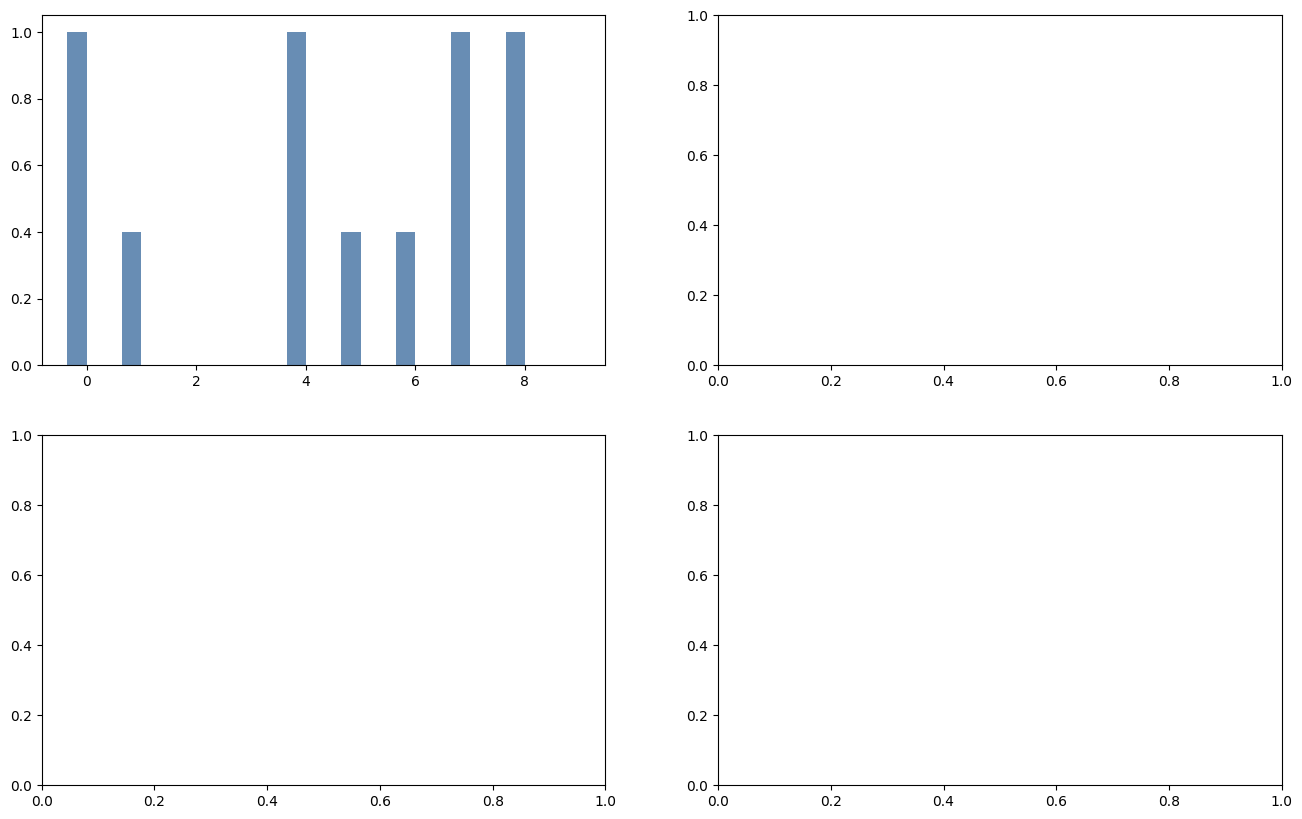

In [ ]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    labels = [r["label"] for r in poc1_results]
    x = np.arange(len(labels))
    w = 0.35
    c1, c2 = "#4e79a7", "#f28e2b"

    # 1 — P@5 per query
    ax = axes[0, 0]
    ax.bar(x - w/2, [r["p@5"] for r in poc1_results],
           w, label="PoC-1", color=c1, alpha=0.85)
    ax.bar(x + w/2, [r["p@5"] for r in poc2_results],
           w, label="PoC-2", color=c2, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("P@5")
    ax.set_title("Precision@5 per query")
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", label="50% baseline")

    # 2 — MRR per query
    ax = axes[0, 1]
    ax.bar(x - w/2, [r["mrr"] for r in poc1_results],
           w, label="PoC-1", color=c1, alpha=0.85)
    ax.bar(x + w/2, [r["mrr"] for r in poc2_results],
           w, label="PoC-2", color=c2, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("MRR")
    ax.set_title("Mean Reciprocal Rank per query")
    ax.legend()
    ax.set_ylim(0, 1.1)

    # 3 — P@10 per query
    ax = axes[1, 0]
    ax.bar(x - w/2, [r.get("p@10", 0) for r in poc1_results],
           w, label="PoC-1", color=c1, alpha=0.85)
    ax.bar(x + w/2, [r.get("p@10", 0) for r in poc2_results],
           w, label="PoC-2", color=c2, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("P@10")
    ax.set_title("Precision@10 per query")
    ax.legend()
    ax.set_ylim(0, 1.1)

    # 4 — Score spread (proxy for retriever confidence)
    ax = axes[1, 1]
    ax.bar(x - w/2, [r.get("score_spread", 0)
           for r in poc1_results], w, label="PoC-1", color=c1, alpha=0.85)
    ax.bar(x + w/2, [r.get("score_spread", 0)
           for r in poc2_results], w, label="PoC-2", color=c2, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Score std dev")
    ax.set_title("Score spread (higher = more confident ranking)")
    ax.legend()

    plt.suptitle(
        "PoC-1 (mpnet+RRF) vs PoC-2 (SPLADE+mpnet+RRF) — Full Benchmark", fontsize=13)
    plt.tight_layout()
    plt.savefig("benchmark_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved to benchmark_comparison.png")

    # Summary table
    print("\n── Aggregate summary ─────────────────────────────")
    for name, results in [("PoC-1", poc1_results), ("PoC-2", poc2_results)]:
        p5 = np.mean([r["p@5"] for r in results])
        p10 = np.mean([r.get("p@10", 0) for r in results])
        mrr = np.mean([r["mrr"] for r in results])
        lat = np.mean([r["latency_ms"] for r in results])
        print(
            f"  {name}: mean P@5={p5:.3f}  P@10={p10:.3f}  MRR={mrr:.3f}  latency={lat:.0f}ms")

except ImportError:
    print("matplotlib not installed — pip install matplotlib")

### Novel Documents — What Each System Finds Uniquely

In [ ]:
print("Documents found by PoC-2 but NOT by PoC-1 (novel SPLADE retrievals)\n")
for r1, r2, gq in zip(poc1_results, poc2_results, GOLD_QUERIES):
    ids1 = {h["_id"] for h in r1["hits"][:5]}
    ids2 = {h["_id"] for h in r2["hits"][:5]}
    novel_in_2 = ids2 - ids1
    novel_in_1 = ids1 - ids2
    if novel_in_2 or novel_in_1:
        print(f"  [{r1['label']}]")
        if novel_in_2:
            for h in r2["hits"][:5]:
                if h["_id"] in novel_in_2:
                    s = h["_source"]
                    print(f"    PoC-2 unique: suffix={s.get('suffix')} "
                          f"mfg={s.get('Manufacturer')} "
                          f"T={s.get('MagneticFieldStrength')}   "
                          f"{s.get('description_text', '')[:60]}")
        if novel_in_1:
            for h in r1["hits"][:5]:
                if h["_id"] in novel_in_1:
                    s = h["_source"]
                    print(f"    PoC-1 unique: suffix={s.get('suffix')} "
                          f"mfg={s.get('Manufacturer')} "
                          f"T={s.get('MagneticFieldStrength')}   "
                          f"{s.get('description_text', '')[:60]}")

Documents found by PoC-2 but NOT by PoC-1 (novel SPLADE retrievals)

  [BOLD suffix]
    PoC-2 unique: suffix=sbref mfg=Siemens T=3.0   single-band reference image for multiband fMRI | task: tempo
    PoC-2 unique: suffix=bold mfg=None T=None   BOLD functional MRI | task: overt_verb_generation | Repetiti
    PoC-2 unique: suffix=sbref mfg=Siemens T=3.0   single-band reference image for multiband fMRI | task: tempo
    PoC-1 unique: suffix=bold mfg=None T=None   BOLD functional MRI | task: cuedSGT | RepetitionTime=2.0s | 
    PoC-1 unique: suffix=bold mfg=None T=None   BOLD functional MRI | task: cuedSGT | RepetitionTime=2.0s | 
    PoC-1 unique: suffix=bold mfg=Siemens T=3.0   BOLD functional MRI | task: facerecognition | 3T | Siemens T
  [T1w suffix]
    PoC-2 unique: suffix=T1w mfg=GE T=3.0   T1-weighted anatomical structural MRI | 3T | GE DISCOVERY MR
    PoC-2 unique: suffix=T1w mfg=GE T=3.0   T1-weighted anatomical structural MRI | 3T | GE DISCOVERY MR
    PoC-2 unique: suffix=T1w

---
## Conclusion

### Architecture comparison

```
PoC-1 (A+B+D)
  query → expand_query() → BM25  ─────────────────┐
                         → all-mpnet kNN ──────────┤→ rrf_fuse() → top-k

PoC-2 (B+C+D)
  query → expand_query() → BM25  ─────────────────┐
                         → SPLADE sparse_vector ───┤→ rrf_fuse() → top-k
                         → all-mpnet kNN ──────────┘
```

### When SPLADE wins (PoC-2 > PoC-1)
- Queries with strong synonym/expansion needs (e.g., *"resting state"* → tokens
  `rest`, `task`, `paradigm`, `rsfMRI` weighted contextually)
- Queries where BM25 literal matching misses synonyms that SPLADE has learned
  from MS-MARCO fine-tuning

### When they tie
- Queries with highly specific metadata values (`MagneticFieldStrength=3.0`,
  `Manufacturer=Siemens`) — both systems find the same docs via keyword/kNN

### Cost

| | PoC-1 | PoC-2 |
|--|-------|-------|
| ES license | Basic (free) | Basic (free) |
| External models | HuggingFace (Apache/MIT) | HuggingFace (Apache/MIT) |
| ES subscription | ❌ none | ❌ none |
| Extra compute | dense embed only | dense + SPLADE (2-3× ingest time) |

**Recommendation:** Start with PoC-1 (faster ingest, good quality). Upgrade
to PoC-2 if synonym-heavy queries dominate your workload and ingest latency
is acceptable. Both are production-ready without any Elastic subscription.